Random_state:  63
              precision    recall  f1-score   support

        Heal       0.45      0.71      0.56         7
         Not       0.00      0.00      0.00         6

    accuracy                           0.38        13
   macro avg       0.23      0.36      0.28        13
weighted avg       0.24      0.38      0.30        13

Accuracy: 38.46153846153847 %


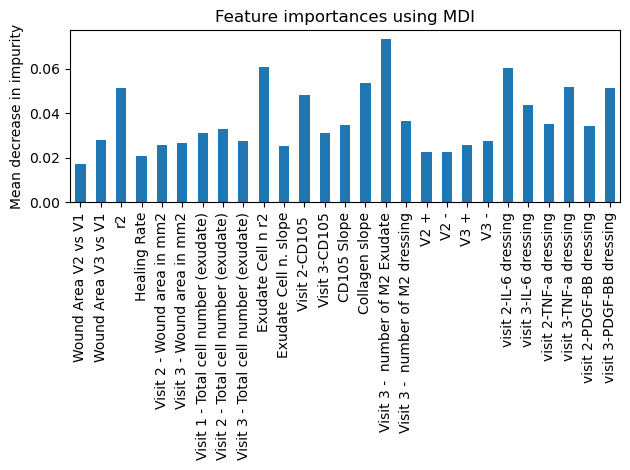

[[0.7716926  0.22830744]
 [0.46075696 0.53924304]
 [0.6385575  0.3614425 ]
 [0.22304028 0.7769597 ]
 [0.82901424 0.17098576]
 [0.91295713 0.08704288]
 [0.9250504  0.07494959]
 [0.9605978  0.0394022 ]
 [0.9220886  0.0779114 ]
 [0.73881483 0.26118517]
 [0.58720386 0.41279614]
 [0.85715485 0.14284517]
 [0.6026442  0.39735577]]


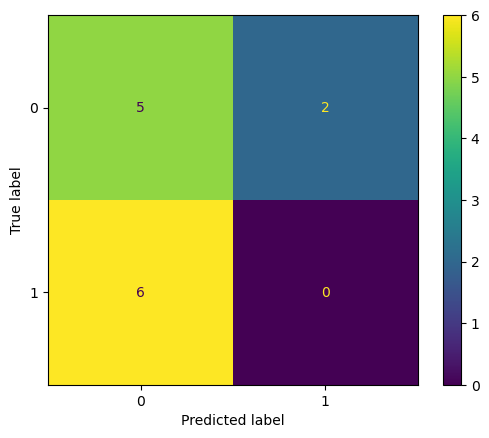

<Figure size 40000x12000 with 0 Axes>

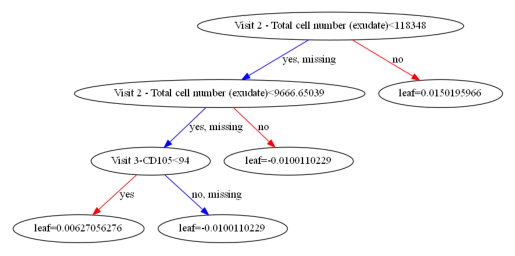

              precision    recall  f1-score   support

        Heal       1.00      1.00      1.00        22
         Not       1.00      1.00      1.00        10

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

--------------------------------------------------------------------------------------------------


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model



W_tree=0
Treatment=pd.read_csv("../AD report/treatment_train.csv")
Treatment_test=pd.read_csv("../AD report/treatment_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]



#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)




R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=25


clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="exact",
              #  objective="survival:cox",
                 # eta=0.01,
                 # max_depth=4,
                  subsample=0.9,
                  colsample_bytree=0.2,
                  colsample_bylevel=0.9,
               #  colsample_bynode=0.6,
                  #reg_lambda=0.6,
                  #reg_alpha=0.5,
                  rate_drop=1,
                  skip_drop=0.3,
                  #one_drop=1,
                  #sample_type="weighted",
                  num_parallel_tree=25,
                  
    )


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 75))
#y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 


class_names=["Heal","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    y_test, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)
